In [ ]:
import numpy as np
import pandas as pd
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from matplotlib import pyplot
import imblearn
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn import datasets
from sklearn.preprocessing import LabelBinarizer

In [ ]:
df = pd.read_excel("/content/perfect_final_data_for_multilevel_analysis.xlsx")
df

,V001,V002,V012,V013,V024,V025,V106,V113,V130,V157,...,Number_of_children,Living_children,Age_of_husband,profession_of_husband,Birth_Interval,Drinking_water,Wealth_Status,Religion_status,BMI,Respondent_Age_first_birth
0,469,57,48,7,6,2,0,21,1,0,...,2,2,2,1,4,2,0,1,4,1
1,438,26,32,4,6,1,2,21,1,0,...,1,1,1,2,1,2,2,1,4,0
2,296,96,39,5,4,1,2,21,1,0,...,2,2,2,4,1,2,2,1,4,1
3,438,4,48,7,6,1,0,21,1,0,...,2,2,2,2,1,2,2,1,4,0
4,548,158,32,4,7,2,3,12,1,0,...,1,1,1,1,2,1,0,1,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8497,417,132,41,6,5,2,1,21,1,0,...,2,1,2,1,3,2,0,1,1,0
8498,190,11,43,6,3,1,0,11,1,0,...,1,1,1,3,3,1,1,1,1,1
8499,123,123,40,6,2,2,0,21,1,0,...,1,1,2,2,1,2,0,1,1,1
8500,581,64,30,4,7,2,1,21,2,0,...,2,2,1,2,2,2,0,0,1,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   V001                        8502 non-null   int64  
 1   V002                        8502 non-null   int64  
 2   V012                        8502 non-null   int64  
 3   V013                        8502 non-null   int64  
 4   V024                        8502 non-null   int64  
 5   V025                        8502 non-null   int64  
 6   V106                        8502 non-null   int64  
 7   V113                        8502 non-null   int64  
 8   V130                        8502 non-null   int64  
 9   V157                        8502 non-null   int64  
 10  V158                        8502 non-null   int64  
 11  V159                        8502 non-null   int64  
 12  V190                        8502 non-null   int64  
 13  V201                        8502 

In [ ]:
df.drop(columns=['V001', 'V002', 'V012', 'V113', 'V130', 'V157', 'V158',
                 'V159', 'V190', 'V201', 'V212', 'V218', 'V221', 'V364', 'V445','V447', 'V501',
                 'V502', 'V701', 'V705', 'V730'], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   V013                        8502 non-null   int64  
 1   V024                        8502 non-null   int64  
 2   V025                        8502 non-null   int64  
 3   V106                        8502 non-null   int64  
 4   V404                        8502 non-null   int64  
 5   V714                        8502 non-null   int64  
 6   BMI_fixed                   8502 non-null   float64
 7   Media_acccess               8502 non-null   int64  
 8   husband_education           8502 non-null   int64  
 9   contraceptive_use           8502 non-null   int64  
 10  Number_of_children          8502 non-null   int64  
 11  Living_children             8502 non-null   int64  
 12  Age_of_husband              8502 non-null   int64  
 13  profession_of_husband       8502 

In [ ]:
df.drop(columns=['BMI_fixed'], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   V013                        8502 non-null   int64
 1   V024                        8502 non-null   int64
 2   V025                        8502 non-null   int64
 3   V106                        8502 non-null   int64
 4   V404                        8502 non-null   int64
 5   V714                        8502 non-null   int64
 6   Media_acccess               8502 non-null   int64
 7   husband_education           8502 non-null   int64
 8   contraceptive_use           8502 non-null   int64
 9   Number_of_children          8502 non-null   int64
 10  Living_children             8502 non-null   int64
 11  Age_of_husband              8502 non-null   int64
 12  profession_of_husband       8502 non-null   int64
 13  Birth_Interval              8502 non-null   int64
 14  Drinking

In [ ]:
df.info()  # check the data types and missing values again

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   V013                        8502 non-null   int64
 1   V024                        8502 non-null   int64
 2   V025                        8502 non-null   int64
 3   V106                        8502 non-null   int64
 4   V404                        8502 non-null   int64
 5   V714                        8502 non-null   int64
 6   Media_acccess               8502 non-null   int64
 7   husband_education           8502 non-null   int64
 8   contraceptive_use           8502 non-null   int64
 9   Number_of_children          8502 non-null   int64
 10  Living_children             8502 non-null   int64
 11  Age_of_husband              8502 non-null   int64
 12  profession_of_husband       8502 non-null   int64
 13  Birth_Interval              8502 non-null   int64
 14  Drinking

In [ ]:
# FT4_df.head()  # this would preview the robust scaled data
y = df.BMI  # use bmi1 as the target variable
x = df.drop('BMI', axis=1)  # use the other columns as features

In [ ]:
y  # display the target column

,BMI
0,4
1,4
2,4
3,4
4,4
...,...
8497,1
8498,1
8499,1
8500,1


In [ ]:
x  # display the feature columns

,V013,V024,V025,V106,V404,V714,Media_acccess,husband_education,contraceptive_use,Number_of_children,Living_children,Age_of_husband,profession_of_husband,Birth_Interval,Drinking_water,Wealth_Status,Religion_status,Respondent_Age_first_birth
0,7,6,2,0,0,0,0,0,0,2,2,2,1,4,2,0,1,1
1,4,6,1,2,0,1,1,2,0,1,1,1,2,1,2,2,1,0
2,5,4,1,2,0,0,1,3,1,2,2,2,4,1,2,2,1,1
3,7,6,1,0,0,0,1,2,0,2,2,2,2,1,2,2,1,0
4,4,7,2,3,0,0,0,1,0,1,1,1,1,2,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8497,6,5,2,1,0,0,0,0,1,2,1,2,1,3,2,0,1,0
8498,6,3,1,0,0,0,1,0,0,1,1,1,3,3,1,1,1,1
8499,6,2,2,0,0,0,0,0,1,1,1,2,2,1,2,0,1,1
8500,4,7,2,1,1,0,1,1,1,2,2,1,2,2,2,0,0,1


In [ ]:
ohe_columns = [
    'Media_acccess', # Column for media access
    'husband_education', # Column for husband's education
    'contraceptive_use', # Column for contraceptive use
    'Number_of_children', # Column for number of children
    'Living_children', # Column for living children
    'Age_of_husband', # Column for age of husband
    'profession_of_husband', # Column for profession of husband
    'Birth_Interval', # Column for birth interval
    'Drinking_water', # Column for drinking water source
    'Wealth_Status', # Column for wealth status
    'Religion_status', # Column for religion status
    'Respondent_Age_first_birth' # Column for respondent's age at first birth
]

x = pd.get_dummies(x, columns=ohe_columns, drop_first=True) # Apply one-hot encoding to specified columns, dropping the first category to avoid multicollinearity
print(x.head()) # Print the first few rows of the DataFrame with the new one-hot encoded columns

   V013  V024  V025  V106  V404  V714  Media_acccess_1  husband_education_1  \
0     7     6     2     0     0     0            False                False   
1     4     6     1     2     0     1             True                False   
2     5     4     1     2     0     0             True                False   
3     7     6     1     0     0     0             True                False   
4     4     7     2     3     0     0            False                 True   

   husband_education_2  husband_education_3  ...  Birth_Interval_5  \
0                False                False  ...             False   
1                 True                False  ...             False   
2                False                 True  ...             False   
3                 True                False  ...             False   
4                False                False  ...             False   

   Birth_Interval_6  Drinking_water_1  Drinking_water_2  Drinking_water_3  \
0             False        

In [ ]:
y = LabelEncoder().fit_transform(y)  # change target labels into numbers
oversample = SMOTE()  # create SMOTE to balance classes
x, y = oversample.fit_resample(x, y)  # make class counts more balanced
counter = Counter(y)  # count samples in each class
for k, v in counter.items():  # loop through each class count
  per = v / len(y) * 100  # calculate class percentage
  print('class=%d, count=%d, percentage=%.3f%%' % (k, v, per))  # print class distribution

class=3, count=4469, percentage=25.000%
class=2, count=4469, percentage=25.000%
class=1, count=4469, percentage=25.000%
class=0, count=4469, percentage=25.000%


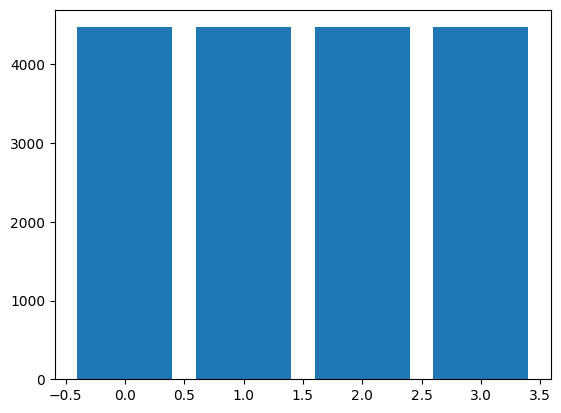

In [ ]:
pyplot.bar(counter.keys(), counter.values())  # draw a bar chart for class counts
pyplot.show()  # show the chart

In [ ]:
from sklearn.model_selection import train_test_split  # import the train-test split tool
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=101)  # split data into training and testing sets
x_train.head()  # preview the training features
x_train.shape  # check the training data shape

(12513, 35)

In [ ]:
x_test.head()  # preview the testing features
x_test.shape  # check the testing data shape

(5363, 35)

In [ ]:
# logistic regression
from sklearn.linear_model import LogisticRegression  # import logistic regression
Lr = LogisticRegression()  # create the model
Lr.fit(x_train, y_train)  # train the model on the training data

# Generate predictions for both test and training data
predictions = Lr.predict(x_test)  # predict labels for the test set
train_predictions = Lr.predict(x_train)  # predict labels for the training set

from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools

# Train performance
print("=== Training Performance ===")  # print training results heading
print(classification_report(y_train, train_predictions, digits=4))  # show training metrics
print(confusion_matrix(y_train, train_predictions))  # show training confusion matrix
# test performance
print("=== Test Performance ===")  # print test results heading
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = Lr.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities for ROC work

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # measure agreement between true and predicted labels

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(Lr, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Training Performance ===
              precision    recall  f1-score   support

           0     0.5892    0.6269    0.6075      3120
           1     0.5027    0.6348    0.5610      3113
           2     0.4257    0.2449    0.3109      3112
           3     0.5691    0.6237    0.5952      3168

    accuracy                         0.5330     12513
   macro avg     0.5217    0.5326    0.5186     12513
weighted avg     0.5219    0.5330    0.5190     12513

[[1956  551  133  480]
 [ 389 1976  509  239]
 [ 479 1094  762  777]
 [ 496  310  386 1976]]
=== Test Performance ===
              precision    recall  f1-score   support

           0     0.5997    0.6175    0.6085      1349
           1     0.4934    0.6372    0.5562      1356
           2     0.4354    0.2432    0.3121      1357
           3     0.5563    0.6264    0.5893      1301

    accuracy                         0.5299      5363
   macro avg     0.5212    0.5311    0.5165      5363
weighted avg     0.5207    0.5299    0

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Cross Validation Scores are [0.51342282 0.5458613  0.53747204 0.53243848 0.53243848 0.53243848
 0.54057079 0.52266368 0.52714046 0.52602126 0.5246085  0.53076063
 0.51733781 0.53020134 0.53020134 0.51677852 0.52154449 0.52658086
 0.53161724 0.55232233 0.54082774 0.53299776 0.50279642 0.52404922
 0.53020134 0.53691275 0.50867375 0.54392837 0.52546167 0.5383324 ]
Average Cross Validation score :0.5292200756394992


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier  # import decision tree model
dtree = DecisionTreeClassifier()  # create the model
dtree.fit(x_train, y_train)  # train the model
predictions = dtree.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = dtree.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(dtree, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.7464    0.7961    0.7704      1349
           1     0.4958    0.4329    0.4622      1356
           2     0.5454    0.5048    0.5243      1357
           3     0.7237    0.8255    0.7713      1301

    accuracy                         0.6377      5363
   macro avg     0.6278    0.6398    0.6321      5363
weighted avg     0.6267    0.6377    0.6304      5363

[[1074  144   79   52]
 [ 212  587  384  173]
 [ 114  373  685  185]
 [  39   80  108 1074]]
Cross Validation Scores are [0.65995526 0.66275168 0.67002237 0.66387025 0.65380313 0.67785235
 0.67039731 0.64745383 0.67431449 0.66480134 0.66051454 0.6582774
 0.66275168 0.68680089 0.67337808 0.68456376 0.64689424 0.66032457
 0.66871852 0.66480134 0.66387025 0.67281879 0.65268456 0.67058166
 0.64821029 0.66666667 0.66200336 0.67599328 0.65864578 0.66927812]
Average Cross Validation score :0.6650999930311176


In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier  # import random forest model
rfc = RandomForestClassifier(n_estimators=100)  # create the model with 100 trees
rfc.fit(x_train, y_train)  # train the model
predictions = rfc.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = rfc.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(rfc, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.8056    0.8599    0.8318      1349
           1     0.6029    0.5553    0.5781      1356
           2     0.6506    0.6080    0.6286      1357
           3     0.8265    0.8932    0.8585      1301

    accuracy                         0.7272      5363
   macro avg     0.7214    0.7291    0.7243      5363
weighted avg     0.7202    0.7272    0.7227      5363

[[1160  109   42   38]
 [ 169  753  338   96]
 [  90  332  825  110]
 [  21   55   63 1162]]
Cross Validation Scores are [0.76286353 0.77237136 0.75559284 0.75447427 0.74888143 0.76454139
 0.74650252 0.75713486 0.75321768 0.76217124 0.76677852 0.75
 0.75838926 0.75782998 0.75055928 0.76733781 0.75097929 0.73531058
 0.73922776 0.75713486 0.74384787 0.75671141 0.75111857 0.77237136
 0.75615213 0.75055928 0.75433688 0.73866816 0.75209849 0.75657527]
Average Cross Validation score :0.7547912631913225


In [ ]:
# K- nearest neighbor
from sklearn.neighbors import KNeighborsClassifier  # import KNN model
KN = KNeighborsClassifier()  # create the model
KN.fit(x_train, y_train)  # train the model
predictions = KN.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = KN.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(KN, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.6575    0.9236    0.7682      1349
           1     0.6099    0.3193    0.4192      1356
           2     0.6390    0.5099    0.5672      1357
           3     0.7110    0.9154    0.8004      1301

    accuracy                         0.6642      5363
   macro avg     0.6543    0.6671    0.6387      5363
weighted avg     0.6538    0.6642    0.6369      5363

[[1246   24   32   47]
 [ 406  433  308  209]
 [ 204  233  692  228]
 [  39   20   51 1191]]
Cross Validation Scores are [0.70246085 0.700783   0.69239374 0.70525727 0.69574944 0.69463087
 0.68998321 0.6927812  0.69949636 0.69893677 0.71532438 0.70973154
 0.70693512 0.71085011 0.68344519 0.700783   0.67711248 0.68606603
 0.69669838 0.69334079 0.68288591 0.7114094  0.68232662 0.69742729
 0.69686801 0.71252796 0.70173475 0.6922216  0.70173475 0.69445999]
Average Cross Validation score :0.6975452007142479


In [ ]:
# GaussianNB
from sklearn.naive_bayes import GaussianNB  # import Gaussian Naive Bayes model
NB = GaussianNB()  # create the model
NB.fit(x_train, y_train)  # train the model
predictions = NB.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = NB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(NB, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.5255    0.3440    0.4158      1349
           1     0.4612    0.1799    0.2589      1356
           2     0.3913    0.0199    0.0379      1357
           3     0.3122    0.9316    0.4677      1301

    accuracy                         0.3630      5363
   macro avg     0.4226    0.3688    0.2951      5363
weighted avg     0.4236    0.3630    0.2931      5363

[[ 464  101    7  777]
 [ 249  244   24  839]
 [ 129  147   27 1054]
 [  41   37   11 1212]]
Cross Validation Scores are [0.44630872 0.450783   0.43791946 0.44630872 0.43120805 0.45861298
 0.45551203 0.45215445 0.37548965 0.45942921 0.44127517 0.43903803
 0.38087248 0.43456376 0.43624161 0.45637584 0.45439284 0.4415221
 0.46894236 0.44376049 0.47315436 0.45469799 0.42505593 0.44407159
 0.44854586 0.37472036 0.44711807 0.44599888 0.43984331 0.44599888]
Average Cross Validation score :0.44033053993816473


In [ ]:
# support vector machine
from sklearn.svm import LinearSVC  # import linear SVM model
classifier = LinearSVC()  # create the model
classifier.fit(x_train, y_train)  # train the model
y_predict = classifier.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, y_predict, digits=4))  # show test metrics
print(confusion_matrix(y_test, y_predict))  # show test confusion matrix
y_score = classifier.fit(x_train, y_train).decision_function(x_test)  # get decision scores

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, y_predict)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(classifier, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.5846    0.6457    0.6136      1349
           1     0.4924    0.6475    0.5594      1356
           2     0.4573    0.1577    0.2345      1357
           3     0.5210    0.6495    0.5782      1301

    accuracy                         0.5236      5363
   macro avg     0.5138    0.5251    0.4964      5363
weighted avg     0.5136    0.5236    0.4954      5363

[[871 230  31 217]
 [197 878 129 152]
 [233 502 214 408]
 [189 173  94 845]]
Cross Validation Scores are [0.52348993 0.53243848 0.52684564 0.52572707 0.52348993 0.53020134
 0.53161724 0.51259093 0.53385562 0.52378288 0.52404922 0.52293065
 0.5139821  0.52516779 0.52293065 0.50894855 0.52154449 0.52042529
 0.53329603 0.55008394 0.53467562 0.53243848 0.50559284 0.51957494
 0.52908277 0.5212528  0.51762731 0.538892   0.52210409 0.53609401]
Average Cross Validation score :0.5254910871331477


In [ ]:
# AdaBoostClassifier
from sklearn.ensemble import AdaBoostClassifier  # import AdaBoost model
abc = AdaBoostClassifier(n_estimators=50, learning_rate=1)  # create the model
model = abc.fit(x_train, y_train)  # train the model
y_pred = model.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, y_pred, digits=4))  # show test metrics
print(confusion_matrix(y_test, y_pred))  # show test confusion matrix
y_score = abc.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(abc, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.5081    0.6783    0.5810      1349
           1     0.4453    0.3665    0.4021      1356
           2     0.3433    0.1776    0.2341      1357
           3     0.4581    0.6141    0.5248      1301

    accuracy                         0.4572      5363
   macro avg     0.4387    0.4591    0.4355      5363
weighted avg     0.4384    0.4572    0.4343      5363

[[915 182  83 169]
 [421 497 170 268]
 [287 321 241 508]
 [178 116 208 799]]
Cross Validation Scores are [0.44854586 0.44798658 0.44630872 0.45917226 0.43288591 0.46923937
 0.4616676  0.45886961 0.44935646 0.45383324 0.47427293 0.45022371
 0.46756152 0.45637584 0.4401566  0.44463087 0.46054841 0.4420817
 0.44599888 0.45831002 0.47147651 0.450783   0.43512304 0.4541387
 0.45357942 0.43120805 0.43984331 0.44767767 0.4420817  0.43480694]
Average Cross Validation score :0.45095814831367653


In [ ]:
# GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier  # import gradient boosting model
GB = GradientBoostingClassifier()  # create the model
model = GB.fit(x_train, y_train)  # train the model
predictions = model.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = GB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(GB, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.6200    0.6761    0.6468      1349
           1     0.5062    0.5118    0.5090      1356
           2     0.4483    0.3066    0.3641      1357
           3     0.5794    0.7095    0.6379      1301

    accuracy                         0.5491      5363
   macro avg     0.5385    0.5510    0.5394      5363
weighted avg     0.5379    0.5491    0.5383      5363

[[912 181  76 180]
 [217 694 302 143]
 [205 389 416 347]
 [137 107 134 923]]
Cross Validation Scores are [0.54697987 0.56040268 0.54530201 0.55536913 0.54418345 0.55257271
 0.55623951 0.54448797 0.55623951 0.54896475 0.54530201 0.55760626
 0.54362416 0.5598434  0.5598434  0.54865772 0.53329603 0.53161724
 0.54952434 0.56407387 0.55816555 0.55089485 0.54753915 0.54306488
 0.5598434  0.5458613  0.52490207 0.56015669 0.55344152 0.55344152]
Average Cross Validation score :0.5500480310403206


In [ ]:
# XGBoost
from numpy import loadtxt  # import loadtxt from NumPy
from xgboost import XGBClassifier  # import XGBoost model
XGB = XGBClassifier()  # create the model
model = XGB.fit(x_train, y_train)  # train the model
predictions = model.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = XGB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(XGB, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.7802    0.8102    0.7949      1349
           1     0.5562    0.5693    0.5627      1356
           2     0.5785    0.4967    0.5345      1357
           3     0.7743    0.8386    0.8052      1301

    accuracy                         0.6769      5363
   macro avg     0.6723    0.6787    0.6743      5363
weighted avg     0.6711    0.6769    0.6728      5363

[[1093  137   55   64]
 [ 141  772  361   82]
 [ 130  381  674  172]
 [  37   98   75 1091]]
Cross Validation Scores are [0.69798658 0.69854586 0.69071588 0.71029083 0.68232662 0.68624161
 0.68606603 0.68382764 0.68998321 0.6927812  0.69127517 0.68680089
 0.7041387  0.70022371 0.68736018 0.68959732 0.69334079 0.67431449
 0.6922216  0.70173475 0.67841163 0.68176734 0.68064877 0.7147651
 0.70190157 0.69295302 0.68718523 0.68998321 0.68998321 0.70173475]
Average Cross Validation score :0.6919702303528634


In [ ]:
# Bagging
from sklearn.ensemble import BaggingClassifier
BC=BaggingClassifier()
model=BC.fit(x_train, y_train)
predictions = model.predict(x_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,predictions,digits=4))
print(confusion_matrix(y_test,predictions))
y_score = BC.fit(x_train, y_train).predict_proba(x_test)

from sklearn.metrics import cohen_kappa_score
cohen_kappa_score(y_test,predictions)

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import  cross_val_score,KFold
kf = RepeatedStratifiedKFold(n_splits = 10, n_repeats=3, random_state=1)
scores = cross_val_score(BC, x, y, cv = kf)
print("Cross Validation Scores are {}".format(scores))
print("Average Cross Validation score :{}".format(scores.mean()))

              precision    recall  f1-score   support

           0     0.7384    0.8577    0.7936      1349
           1     0.5625    0.4978    0.5282      1356
           2     0.6019    0.5505    0.5751      1357
           3     0.8081    0.8417    0.8245      1301

    accuracy                         0.6851      5363
   macro avg     0.6777    0.6869    0.6803      5363
weighted avg     0.6763    0.6851    0.6787      5363

[[1157  101   47   44]
 [ 228  675  353  100]
 [ 143  351  747  116]
 [  39   73   94 1095]]
Cross Validation Scores are [0.7147651  0.71532438 0.71532438 0.71532438 0.69910515 0.70805369
 0.70005596 0.70341354 0.70005596 0.7112479  0.7114094  0.7114094
 0.70246085 0.71756152 0.7041387  0.71420582 0.70733072 0.69501959
 0.70621153 0.72076105 0.70134228 0.71085011 0.71588367 0.71085011
 0.70190157 0.70861298 0.69501959 0.69725797 0.71628428 0.7112479 ]
Average Cross Validation score :0.7080809825873917


In [ ]:
# Model Accuracy Summary
# Logistic Regression - 53%
# Decision Tree - 67%
# Random Forest - 75%
# K-nearest neighbor - 70%
# GaussianNB - 44%
# LinearSVC - 53%
# AdaBoostClassifier - 45%
# GradientBoostingClassifier - 55%
# XGBoost - 69%
# BaggingClassifier - 71%